In [59]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils.data_helper import *
from utils.data import *
from utils.performance import *
from utils.ta import *

import warnings
# Suppress the interpolation warning from KPSS test
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
instruments = [
    'META',
    'TSLA',
    'NVDA',
    'AAPL',        
    'BRK-B',
    'SPY',
    'QQQ',
    'NANC',        
    'CASH'
]

end_date = datetime.today() - BDay(1)
start_date = end_date - BDay(250)

In [61]:
df_px = get_yahoo_data_formatted(instruments=instruments, start_date=start_date, end_date=end_date)

[*********************100%***********************]  8 of 8 completed


# Mean reversion analysis

In [62]:
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss

ret_windows = 20
ret_delay = 20


MEAN REVERSION ANALYSIS SUMMARY
Ticker  Correlation     Slope  Lag20_AutoCorr  R-squared  P-value  ADF_Stat  ADF_PVal  KPSS_Stat  KPSS_PVal    Hurst  Half_Life_Days  N_Obs
  META    -0.118086 -0.106484       -0.113881   0.013944 0.095842 -2.675665  0.078345   0.398281   0.077896 0.955890       10.842884    200
  TSLA    -0.226272 -0.231532       -0.303632   0.051199 0.001274 -3.923130  0.001871   0.138049   0.100000 1.000000        8.685220    200
  NVDA    -0.052466 -0.047510       -0.065634   0.002753 0.460616 -2.761666  0.063962   0.469640   0.048504 0.941403       10.017242    200
  AAPL    -0.021203 -0.017928       -0.037963   0.000450 0.765697 -3.167075  0.021971   0.474520   0.047405 0.775265        6.325146    200
 BRK-B    -0.062315 -0.063664       -0.066814   0.003883 0.380708 -3.236060  0.017990   0.340422   0.100000 0.950367        6.757680    200
   SPY    -0.421682 -0.316302       -0.468977   0.177816 0.000000 -4.206276  0.000643   0.173860   0.100000 0.898333        5.4


MEAN REVERSION ANALYSIS SUMMARY
Ticker  Correlation     Slope  Lag20_AutoCorr  R-squared  P-value  ADF_Stat  ADF_PVal  KPSS_Stat  KPSS_PVal    Hurst  Half_Life_Days  N_Obs
  META    -0.118086 -0.106484       -0.113881   0.013944 0.095842 -2.675665  0.078345   0.398281   0.077896 0.955890       10.842884    200
  TSLA    -0.226272 -0.231532       -0.303632   0.051199 0.001274 -3.923130  0.001871   0.138049   0.100000 1.000000        8.685220    200
  NVDA    -0.052466 -0.047510       -0.065634   0.002753 0.460616 -2.761666  0.063962   0.469640   0.048504 0.941403       10.017242    200
  AAPL    -0.021203 -0.017928       -0.037963   0.000450 0.765697 -3.167075  0.021971   0.474520   0.047405 0.775265        6.325146    200
 BRK-B    -0.062315 -0.063664       -0.066814   0.003883 0.380708 -3.236060  0.017990   0.340422   0.100000 0.950367        6.757680    200
   SPY    -0.421682 -0.316302       -0.468977   0.177816 0.000000 -4.206276  0.000643   0.173860   0.100000 0.898333        5.4

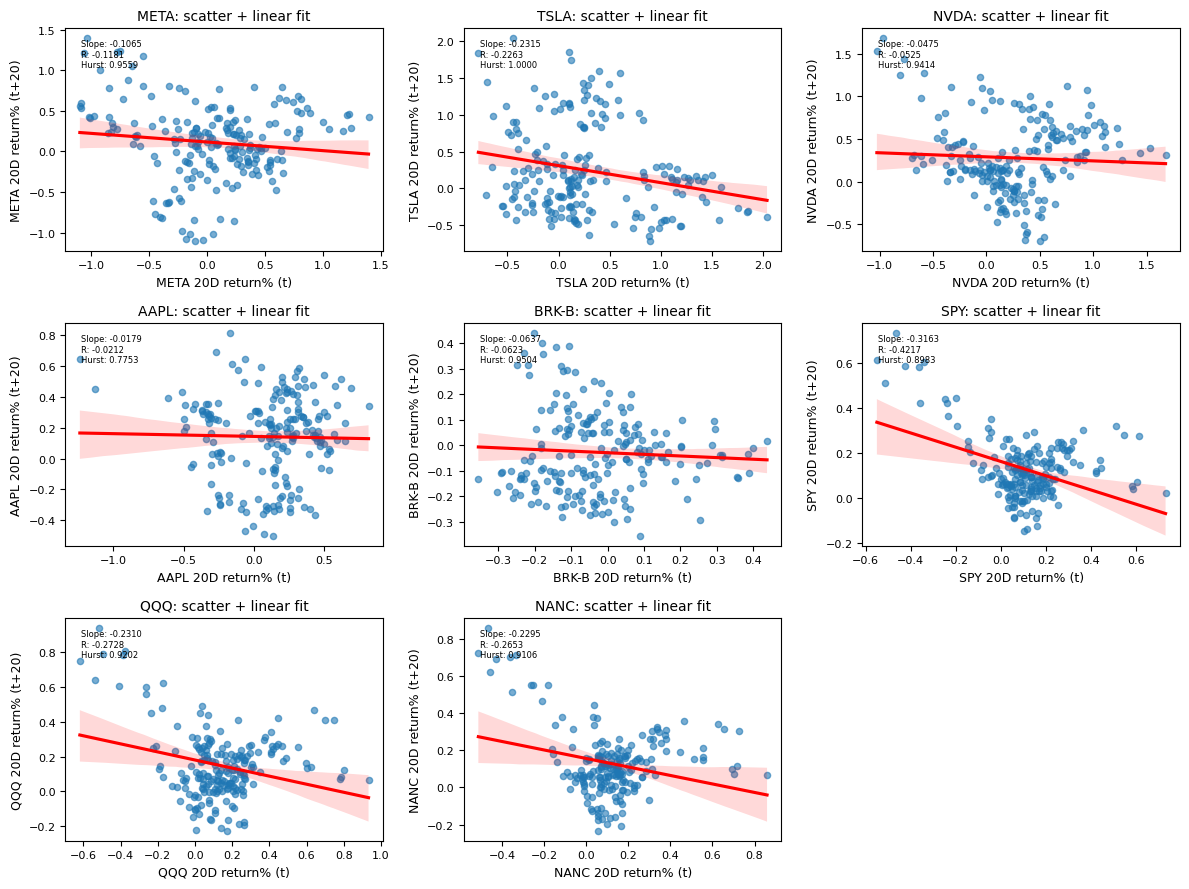

In [63]:
def calculate_hurst_exponent(series, min_lag=10, max_lag=None):
    """
    Calculate Hurst Exponent using Rescaled Range (R/S) Analysis
    H < 0.5 = mean reversion, H = 0.5 = random walk, H > 0.5 = trending
    """
    if max_lag is None:
        max_lag = len(series) // 2
    
    series = np.asarray(series, dtype=np.float64)
    lags = range(min_lag, max_lag)
    rs_values = []
    
    for n in lags:
        # Split series into chunks of size n
        num_chunks = len(series) // n
        rs_list = []
        
        for i in range(num_chunks):
            chunk = series[i*n:(i+1)*n]
            
            # Mean-adjusted series
            mean_chunk = np.mean(chunk)
            Y = np.cumsum(chunk - mean_chunk)
            
            # Range
            R = np.max(Y) - np.min(Y)
            
            # Standard deviation
            S = np.std(chunk, ddof=1)
            
            # Avoid division by zero
            if S > 0:
                rs_list.append(R / S)
        
        # Average R/S for this lag
        if rs_list:
            rs_values.append(np.mean(rs_list))
    
    # Log-log regression: log(RS) = H * log(n) + c
    lags_array = np.array(list(range(min_lag, min_lag + len(rs_values))))
    rs_values = np.array(rs_values)
    
    poly = np.polyfit(np.log(lags_array), np.log(rs_values), 1)
    hurst = poly[0]
    
    # Constrain to valid range [0, 1]
    return np.clip(hurst, 0, 1)

def calculate_half_life(series):
    """Calculate half-life of mean reversion in periods"""
    try:
        y = series.values
        y_lag1 = np.roll(y, 1)[1:]
        y_curr = y[1:]
        delta_y = y_curr - y_lag1
        
        # Fit: delta_y = beta * (y_lag1 - mean)
        y_lag1_centered = y_lag1 - np.mean(y_lag1)
        beta = np.polyfit(y_lag1_centered, delta_y, 1)[0]
        
        if beta >= 0:
            return np.nan
        half_life = -np.log(2) / beta
        return half_life
    except:
        return np.nan
    
n_instruments = len(instruments)
n_cols = 3
n_rows = (n_instruments + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()
stats_list = []

for idx, ticker in enumerate(instruments):

    if ticker == 'CASH':
        axes[idx].set_visible(False)
        continue

    df_ret = np.log(df_px['Close'] / df_px['Close'].shift(1)).dropna() * 100
    df_ret = df_ret.rolling(ret_windows).mean().dropna()
    df_ret_t1 = df_ret.shift(-ret_delay)
    
    x = df_ret[ticker]
    y = df_ret_t1[ticker]
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]

    # Linear Regression Statistics
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    correlation = np.corrcoef(x, y)[0, 1]
    
    # Lag-1 Autocorrelation
    lag_autocorr = x.autocorr(lag=ret_delay)
    
    # ADF Test (H0: unit root exists, reject = stationary/mean reversion)
    try:
        adf_result = adfuller(x, autolag='AIC')
        adf_statistic = adf_result[0]
        adf_pvalue = adf_result[1]
    except:
        adf_statistic, adf_pvalue = np.nan, np.nan
    
    # KPSS Test (H0: stationary, reject = non-stationary)
    try:
        kpss_result = kpss(x, regression='c', nlags='auto')
        kpss_statistic = kpss_result[0]
        kpss_pvalue = kpss_result[1]
    except:
        kpss_statistic, kpss_pvalue = np.nan, np.nan
    
    # Hurst Exponent
    hurst = calculate_hurst_exponent(x.values)
    
    # Half-life of mean reversion
    half_life = calculate_half_life(x)
    
    stats_list.append({
        'Ticker': ticker,
        'Correlation': correlation,
        'Slope': slope,
        f'Lag{ret_delay}_AutoCorr': lag_autocorr,
        'R-squared': r_value**2,
        'P-value': p_value,
        'ADF_Stat': adf_statistic,
        'ADF_PVal': adf_pvalue,
        'KPSS_Stat': kpss_statistic,
        'KPSS_PVal': kpss_pvalue,
        'Hurst': hurst,
        'Half_Life_Days': half_life,
        'N_Obs': len(x)
    })
    
    sns.regplot(x=x, y=y, scatter_kws={'s':20, 'alpha':0.6}, line_kws={'color':'red'}, ax=axes[idx])
    axes[idx].set_xlabel(f'{ticker} {ret_windows}D return% (t)', fontsize=9)
    axes[idx].set_ylabel(f'{ticker} {ret_windows}D return% (t+{ret_delay})', fontsize=9)
    axes[idx].set_title(f'{ticker}: scatter + linear fit', fontsize=10)
    axes[idx].tick_params(labelsize=8)
    axes[idx].annotate(f"Slope: {slope:.4f}\nR: {correlation:.4f}\nHurst: {hurst:.4f}", xy=(0.05,0.95), xycoords='axes fraction', va='top', fontsize=6)

# Create DataFrame and display
stats_df = pd.DataFrame(stats_list)
stats_df = stats_df.round(6)

print("\n" + "="*140)
print("MEAN REVERSION ANALYSIS SUMMARY")
print("="*140)
print(stats_df.to_string(index=False))
print("="*140)
print(f"""
METRIC INTERPRETATION:
- Correlation/Slope: Negative = mean reversion signal
- Lag1_AutoCorr: Negative values indicate mean reversion
- P-value: < 0.05 = significant relationship
- ADF_Stat & ADF_PVal: Lower p-value (<0.05) = stronger evidence of stationarity/mean reversion
- KPSS_Stat & KPSS_PVal: Higher p-value (>0.05) = evidence of stationarity/mean reversion
- Hurst: < 0.5 = mean reversion, = 0.5 = random walk, > 0.5 = trending
- Half_Life_Days: Days for price deviation to revert halfway to mean (lower = faster reversion)
""")
    
plt.tight_layout()
plt.show()

In [64]:
df_px

Price            Close                                                 \
Ticker            AAPL       BRK-B        META       NANC        NVDA   
Date                                                                    
2025-03-10  226.492844  497.100006  596.110229  35.825535  106.950745   
2025-03-11  219.881653  496.250000  603.806030  35.775635  108.730263   
2025-03-12  216.038406  495.940002  617.612427  36.214725  115.719002   
2025-03-13  208.770081  504.250000  588.783386  35.546112  115.559029   
2025-03-14  212.563568  514.599976  606.228882  36.459217  121.647919   
...                ...         ...         ...        ...         ...   
2026-02-13  255.779999  497.549988  639.770020  44.490002  182.809998   
2026-02-17  263.880005  503.410004  639.289978  44.410000  184.970001   
2026-02-18  264.350006  499.070007  643.219971  44.790001  187.979996   
2026-02-19  260.579987  496.940002  644.780029  44.709999  187.899994   
2026-02-20  264.579987  498.200012  655.659973  44.937000  189.820007   

Price                                                 High              ...  \
Ticker             QQQ         SPY        TSLA        AAPL       BRK-B  ...   
Date                                                                    ...   
2025-03-10  470.344635  554.073486  222.149994  235.135185  500.450012  ...   
2025-03-11  469.220306  549.467529  230.580002  224.859955  499.149994  ...   
2025-03-12  474.513489  552.383301  248.089996  220.787711  498.320007  ...   
2025-03-13  465.976746  545.019714  240.679993  215.899013  507.399994  ...   
2025-03-14  477.239655  556.277527  249.979996  213.021563  515.840027  ...   
...                ...         ...         ...         ...         ...  ...   
2026-02-13  601.919983  681.750000  417.440002  262.230011  502.380005  ...   
2026-02-17  601.299988  682.849976  410.630005  266.290009  506.089996  ...   
2026-02-18  605.789978  686.289978  411.320007  266.820007  505.269989  ...   
2026-02-19  603.469971  684.479980  411.709991  264.480011  500.500000  ...   
2026-02-20  608.809998  689.429993  411.820007  264.750000  498.339996  ...   

Price      Volume                                           Close High  Low  \
Ticker       NANC       NVDA       QQQ       SPY       TSLA  CASH CASH CASH   
Date                                                                          
2025-03-10  99100  366487400  76668000  99326600  189076900     1    1    1   
2025-03-11  89400  354865700  68760800  88102100  174896400     1    1    1   
2025-03-12  50700  323857500  46971100  69588200  142215700     1    1    1   
2025-03-13  55100  299033100  46563300  74079400  114813500     1    1    1   
2025-03-14  27000  277593500  43563000  62660300  100242300     1    1    1   
...           ...        ...       ...       ...        ...   ...  ...  ...   
2026-02-13  24100  161888000  69237500  96267500   51434100     1    1    1   
2026-02-17  31300  162276900  69013800  81354700   59678800     1    1    1   
2026-02-18  17200  164749100  64250700  73570300   45921400     1    1    1   
2026-02-19  16000  126554500  60960800  58649400   51019600     1    1    1   
2026-02-20  37200  178143900  74063400  99952100   57843900     1    1    1   

Price      Open Volume  
Ticker     CASH   CASH  
Date                    
2025-03-10    1      1  
2025-03-11    1      1  
2025-03-12    1      1  
2025-03-13    1      1  
2025-03-14    1      1  
...         ...    ...  
2026-02-13    1      1  
2026-02-17    1      1  
2026-02-18    1      1  
2026-02-19    1      1  
2026-02-20    1      1  

[240 rows x 45 columns]

In [65]:
df_px

Price            Close                                                 \
Ticker            AAPL       BRK-B        META       NANC        NVDA   
Date                                                                    
2025-03-10  226.492844  497.100006  596.110229  35.825535  106.950745   
2025-03-11  219.881653  496.250000  603.806030  35.775635  108.730263   
2025-03-12  216.038406  495.940002  617.612427  36.214725  115.719002   
2025-03-13  208.770081  504.250000  588.783386  35.546112  115.559029   
2025-03-14  212.563568  514.599976  606.228882  36.459217  121.647919   
...                ...         ...         ...        ...         ...   
2026-02-13  255.779999  497.549988  639.770020  44.490002  182.809998   
2026-02-17  263.880005  503.410004  639.289978  44.410000  184.970001   
2026-02-18  264.350006  499.070007  643.219971  44.790001  187.979996   
2026-02-19  260.579987  496.940002  644.780029  44.709999  187.899994   
2026-02-20  264.579987  498.200012  655.659973  44.937000  189.820007   

Price                                                 High              ...  \
Ticker             QQQ         SPY        TSLA        AAPL       BRK-B  ...   
Date                                                                    ...   
2025-03-10  470.344635  554.073486  222.149994  235.135185  500.450012  ...   
2025-03-11  469.220306  549.467529  230.580002  224.859955  499.149994  ...   
2025-03-12  474.513489  552.383301  248.089996  220.787711  498.320007  ...   
2025-03-13  465.976746  545.019714  240.679993  215.899013  507.399994  ...   
2025-03-14  477.239655  556.277527  249.979996  213.021563  515.840027  ...   
...                ...         ...         ...         ...         ...  ...   
2026-02-13  601.919983  681.750000  417.440002  262.230011  502.380005  ...   
2026-02-17  601.299988  682.849976  410.630005  266.290009  506.089996  ...   
2026-02-18  605.789978  686.289978  411.320007  266.820007  505.269989  ...   
2026-02-19  603.469971  684.479980  411.709991  264.480011  500.500000  ...   
2026-02-20  608.809998  689.429993  411.820007  264.750000  498.339996  ...   

Price      Volume                                           Close High  Low  \
Ticker       NANC       NVDA       QQQ       SPY       TSLA  CASH CASH CASH   
Date                                                                          
2025-03-10  99100  366487400  76668000  99326600  189076900     1    1    1   
2025-03-11  89400  354865700  68760800  88102100  174896400     1    1    1   
2025-03-12  50700  323857500  46971100  69588200  142215700     1    1    1   
2025-03-13  55100  299033100  46563300  74079400  114813500     1    1    1   
2025-03-14  27000  277593500  43563000  62660300  100242300     1    1    1   
...           ...        ...       ...       ...        ...   ...  ...  ...   
2026-02-13  24100  161888000  69237500  96267500   51434100     1    1    1   
2026-02-17  31300  162276900  69013800  81354700   59678800     1    1    1   
2026-02-18  17200  164749100  64250700  73570300   45921400     1    1    1   
2026-02-19  16000  126554500  60960800  58649400   51019600     1    1    1   
2026-02-20  37200  178143900  74063400  99952100   57843900     1    1    1   

Price      Open Volume  
Ticker     CASH   CASH  
Date                    
2025-03-10    1      1  
2025-03-11    1      1  
2025-03-12    1      1  
2025-03-13    1      1  
2025-03-14    1      1  
...         ...    ...  
2026-02-13    1      1  
2026-02-17    1      1  
2026-02-18    1      1  
2026-02-19    1      1  
2026-02-20    1      1  

[240 rows x 45 columns]

In [66]:
def monthly_rebalance_strategy(df_px, capital, rebalance_day=1):
    """
    Monthly rebalancing strategy that allocates capital evenly across all assets.
    Capital is adjusted at each rebalance date based on current portfolio value (gains/losses).
    
    Parameters:
    -----------
    df_px : pd.DataFrame
        Stock prices dataframe with DatetimeIndex (dates) and MultiIndex columns (ticker, OHLC).
        Access via df_px['Close']['AAPL'] gives closing prices for AAPL
    
    capital : float
        Initial total capital to allocate (e.g., 100000)
    
    rebalance_day : int, default=1
        Day of month to rebalance (1 = first business day of month, etc.)
    
    Returns:
    --------
    positions : pd.DataFrame
        Number of shares for each stock daily (only changes on rebalance dates).
        Index: dates, Columns: stock tickers.
        At each rebalance, positions are adjusted so that each asset gets 1/n of current portfolio value.
    """
    
    # Extract close prices
    close_prices = df_px['Close']
    
    # Get unique tickers (excluding 'CASH' if present)
    tickers = [t for t in close_prices.columns if t != 'CASH']
    n_assets = len(tickers)
    
    # Initialize positions dataframe
    positions = pd.DataFrame(0.0, index=close_prices.index, columns=tickers)
    
    # Get month start dates
    month_starts = close_prices.resample('MS').first().index
    
    # Track current portfolio value (starts with initial capital)
    current_portfolio_value = capital
    
    # Rebalance at each month start
    for month_start_date in month_starts:
        # Find the actual trading date at or after month_start_date
        valid_dates = close_prices.index[close_prices.index >= month_start_date]
        
        if len(valid_dates) == 0:
            continue
        
        rebalance_date = valid_dates[0]
        
        # If not the first rebalance, calculate current portfolio value
        if rebalance_date != close_prices.index[0]:
            # Get previous positions and current prices
            prev_positions = positions.loc[positions.index < rebalance_date].iloc[-1]
            prices_on_date = close_prices.loc[rebalance_date]
            # Current portfolio value = sum of (shares * current prices)
            current_portfolio_value = (prev_positions * prices_on_date).sum()
        
        # Capital per asset at this rebalance (based on current portfolio value)
        capital_per_asset = current_portfolio_value / n_assets
        
        # Get closing prices on rebalance date
        prices_on_date = close_prices.loc[rebalance_date]
        
        # Calculate number of shares for each asset (equally weighted)
        shares = capital_per_asset / prices_on_date
        
        # Fill forward the positions from rebalance date until next month
        next_month_start = rebalance_date + pd.DateOffset(months=1)
        mask = (close_prices.index >= rebalance_date) & (close_prices.index < next_month_start)
        
        # Assign shares to all dates in this period
        for ticker in tickers:
            positions.loc[mask, ticker] = shares[ticker]
    
    # Forward fill any remaining dates
    positions = positions.ffill()
    
    return positions


# Example usage
capital = 100_000  # $100,000 capital
positions = monthly_rebalance_strategy(df_px, capital=capital)

MONTHLY REBALANCING STRATEGY WITH DYNAMIC CAPITAL

Initial Capital: $100,000.00
Number of Assets: 8

--- Rebalance Dates and Position Changes ---

Found 11 rebalance dates

Rebalance events with dynamic capital:

Rebalance #1 - 2025-04-01:
  Portfolio Value: $103,555.60
  Capital per Asset: $12,944.45
  Positions:
    AAPL  :    58.25 shares @ $  222.22 = $ 12,944.45
    BRK-B :    24.29 shares @ $  532.99 = $ 12,944.45
    META  :    22.14 shares @ $  584.68 = $ 12,944.45
    NANC  :   358.82 shares @ $   36.08 = $ 12,944.45

Rebalance #2 - 2025-05-01:
  Portfolio Value: $103,753.34
  Capital per Asset: $12,969.17
  Positions:
    AAPL  :    61.06 shares @ $  212.39 = $ 12,969.17
    BRK-B :    24.46 shares @ $  530.23 = $ 12,969.17
    META  :    22.72 shares @ $  570.92 = $ 12,969.17
    NANC  :   354.02 shares @ $   36.63 = $ 12,969.17

Rebalance #3 - 2025-06-02:
  Portfolio Value: $113,370.73
  Capital per Asset: $14,171.34
  Positions:
    AAPL  :    70.47 shares @ $  201.09 = $ 

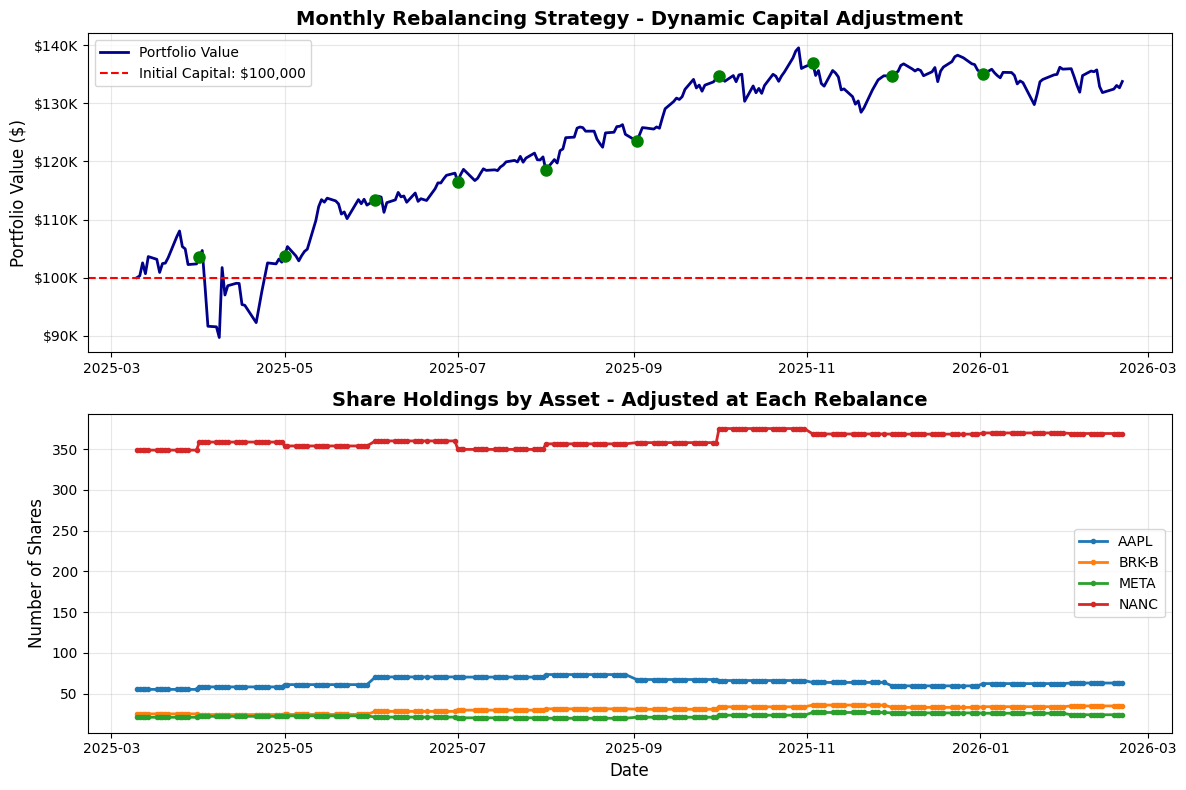


✓ Monthly rebalancing strategy with dynamic capital adjustment complete!
  Position dataframe shape: (240, 8)
  Columns: ['AAPL', 'BRK-B', 'META', 'NANC', 'NVDA', 'QQQ', 'SPY', 'TSLA']


In [67]:
# Detailed example: show positions and portfolio values with dynamic capital tracking
close_prices = df_px['Close']

print("=" * 80)
print("MONTHLY REBALANCING STRATEGY WITH DYNAMIC CAPITAL")
print("=" * 80)

n_assets = len(positions.columns)
initial_capital = capital

print(f"\nInitial Capital: ${initial_capital:,.2f}")
print(f"Number of Assets: {n_assets}")

print("\n--- Rebalance Dates and Position Changes ---")
# Show only rows where positions change
position_changes = positions.diff().fillna(0).abs().sum(axis=1)
rebalance_rows = position_changes[position_changes > 0]
print(f"\nFound {len(rebalance_rows)} rebalance dates")

# Calculate portfolio values for analysis
portfolio_values = (positions * close_prices).sum(axis=1)

print("\nRebalance events with dynamic capital:")
for i, date in enumerate(rebalance_rows.index[:6]):
    # Portfolio value at rebalance (before reallocation)
    pv_at_rebal = portfolio_values.loc[date]
    capital_per_asset = pv_at_rebal / n_assets
    
    print(f"\nRebalance #{i+1} - {date.strftime('%Y-%m-%d')}:")
    print(f"  Portfolio Value: ${pv_at_rebal:,.2f}")
    print(f"  Capital per Asset: ${capital_per_asset:,.2f}")
    print(f"  Positions:")
    
    for ticker in list(positions.columns)[:4]:  # Show first 4
        shares = positions.loc[date, ticker]
        price = close_prices.loc[date, ticker]
        value = shares * price
        print(f"    {ticker:6s}: {shares:8.2f} shares @ ${price:8.2f} = ${value:10,.2f}")

# Calculate portfolio values
print("\n--- Portfolio Value Tracking ---")
portfolio_values = (positions * close_prices).sum(axis=1)
print(f"\nPortfolio value statistics:")
print(f"  Initial:  ${initial_capital:,.2f}")
print(f"  Min:      ${portfolio_values.min():,.2f}")
print(f"  Max:      ${portfolio_values.max():,.2f}")
print(f"  Current:  ${portfolio_values.iloc[-1]:,.2f}")
print(f"  Total Return: {((portfolio_values.iloc[-1] / initial_capital) - 1) * 100:.2f}%")

# Plot positions over time
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Portfolio value over time
axes[0].plot(portfolio_values.index, portfolio_values.values, linewidth=2, color='darkblue', label='Portfolio Value')
axes[0].axhline(initial_capital, color='red', linestyle='--', label=f'Initial Capital: ${initial_capital:,.0f}')

# Mark rebalance dates
for date in rebalance_rows.index[:10]:
    pv = portfolio_values.loc[date]
    axes[0].plot(date, pv, 'go', markersize=8)

axes[0].set_ylabel('Portfolio Value ($)', fontsize=12)
axes[0].set_title('Monthly Rebalancing Strategy - Dynamic Capital Adjustment', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Plot 2: Share counts for selected assets
selected_assets = positions.columns[:4]
for ticker in selected_assets:
    axes[1].plot(positions.index, positions[ticker], label=ticker, linewidth=2, marker='o', markersize=3)

axes[1].set_ylabel('Number of Shares', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_title('Share Holdings by Asset - Adjusted at Each Rebalance', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Monthly rebalancing strategy with dynamic capital adjustment complete!")
print(f"  Position dataframe shape: {positions.shape}")
print(f"  Columns: {list(positions.columns)}")